In [1]:
pip install transformers torch sentence-transformers streamlit

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pandas scikit-learn streamlit

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

In [4]:
df_books = pd.read_csv("data/books.csv")  
df_book_tags = pd.read_csv("data/book_tags.csv")
df_ratings = pd.read_csv("data/ratings.csv")

df_tags = pd.read_csv("data/tags.csv")
df_to_read = pd.read_csv("data/to_read.csv")

pd.set_option('display.max_columns', None)


In [5]:
df_books.shape

(10000, 23)

In [6]:
df_books.head(2)

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...


Revisar libros sin etiquetas

In [7]:
books_with_tags = df_book_tags['goodreads_book_id'].unique()  # Libros que tienen etiquetas
books_without_tags = df_books[~df_books['id'].isin(books_with_tags)]  # Libros sin etiquetas

# Contar el número de libros sin etiquetas
num_books_without_tags = books_without_tags.shape[0]

print(f"Número de libros sin etiquetas: {num_books_without_tags}")


Número de libros sin etiquetas: 9188


Crear un datafre con cada libro y sus etiquetas asociadas

In [8]:
# Agrupar las etiquetas por libro
tag_grouped = df_book_tags.merge(df_tags, on='tag_id', how='left')  # Hacer merge para obtener los nombres de las etiquetas
tag_counts = tag_grouped.groupby('goodreads_book_id')['tag_name'].agg(list).reset_index()  # Agrupar las etiquetas en listas

# Renombrar la columna para mayor claridad
tag_counts.rename(columns={'goodreads_book_id': 'book_id', 'tag_name': 'tags'}, inplace=True)

# Mostrar el resultado
print(tag_counts.head())


   book_id                                               tags
0        1  [to-read, fantasy, favorites, currently-readin...
1        2  [to-read, currently-reading, fantasy, favorite...
2        3  [to-read, favorites, fantasy, currently-readin...
3        5  [favorites, fantasy, currently-reading, young-...
4        6  [fantasy, young-adult, fiction, harry-potter, ...


Merge de los dataframe

In [9]:
# Hacer merge de df_books con tag_counts
df_merged = df_books.merge(tag_counts, on='book_id', how='left')  # Usamos 'left' para mantener todos los libros

# Mostrar la cantidad de libros resultantes
print(f"Número total de libros en el DataFrame combinado: {len(df_merged)}")

Número total de libros en el DataFrame combinado: 10000


In [10]:
df_merged.head(2)

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url,tags
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...,"[favorites, currently-reading, young-adult, fi..."
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...,"[to-read, favorites, fantasy, currently-readin..."


In [11]:
# Contar los libros sin etiquetas (valores NaN en la columna 'tag_name')
num_books_without_tags = df_merged['tags'].isnull().sum()

# Mostrar el número de libros sin etiquetas
print(f"Número de libros sin etiquetas: {num_books_without_tags}")


Número de libros sin etiquetas: 0


Distribución de Calificaciones promedio

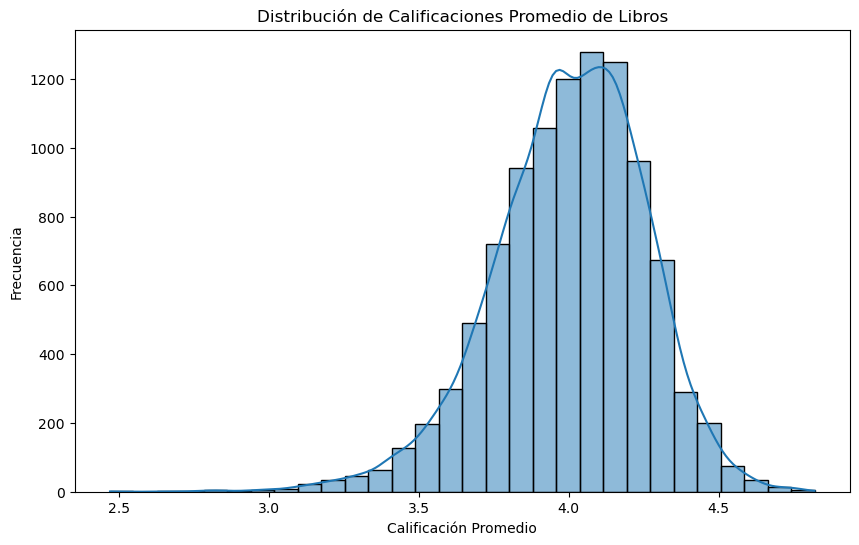

Los 10 libros mejor valorados:
                                                   title  average_rating
3627                     The Complete Calvin and Hobbes            4.82
861      Words of Radiance (The Stormlight Archive, #2)            4.77
3274  Harry Potter Boxed Set, Books 1-5 (Harry Potte...            4.77
7946                                    ESV Study Bible            4.76
8853                           Mark of the Lion Trilogy            4.76
4482  It's a Magical World: A Calvin and Hobbes Coll...            4.75
421            Harry Potter Boxset (Harry Potter, #1-7)            4.74
6360  There's Treasure Everywhere: A Calvin and Hobb...            4.74
3752       Harry Potter Collection (Harry Potter, #1-6)            4.73
6589  The Authoritative Calvin and Hobbes: A Calvin ...            4.73


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Análisis de la distribución de calificaciones
plt.figure(figsize=(10, 6))
sns.histplot(df_merged['average_rating'], bins=30, kde=True)
plt.title('Distribución de Calificaciones Promedio de Libros')
plt.xlabel('Calificación Promedio')
plt.ylabel('Frecuencia')
plt.show()

# Identificar los libros más valorados
top_rated_books = df_merged.nlargest(10, 'average_rating')[['title', 'average_rating']]
print("Los 10 libros mejor valorados:\n", top_rated_books)


Combinar atributos en una nueva columna

In [13]:
# Combinar título, autores y etiquetas en un solo string
df_merged['content'] = df_merged['title'] + ' ' + df_merged['authors'] + ' ' + df_merged['tags'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')


In [14]:
df_merged.shape

(10000, 25)

In [15]:
df_merged.to_csv('data/df_merged.csv', index=False)